> # 1. Resumo Funções Importantes

In [1]:
from Requirements import *

In [29]:
def qc_generator(num_qubits, depth, clifford=False, gates=None, measure=False, gate_density=0.5, one_qubit_distribution=0.7):
    
    """
    Gera um circuito quântico aleatório com registro principal garantido.
    
    Args:
        num_qubits: Número de qubits
        depth: Profundidade do circuito (número de camadas)
        clifford: Se True, usa apenas gates Clifford
        gates: Tupla (gates_1q, gates_2q) ou None para usar padrão
        measure: Se True, adiciona medição no final
        gate_density: Densidade de gates nos registros secundários (0.0 a 1.0)
                      0 = apenas registro principal preenchido
                      1 = circuito inteiro preenchido
        one_qubit_distribution: Fração de gates que devem ser de 1 qubit (0.0 a 1.0)
    
    Returns:
        QuantumCircuit: Circuito quântico gerado
    """
    
    if depth == 0 or num_qubits == 0:
        return QuantumCircuit(num_qubits)
    
    gate_density = max(0.0, min(1.0, gate_density))
    one_qubit_distribution = max(0.0, min(1.0, one_qubit_distribution))

    if gates is None:
        
        if clifford:
            
            one_qubit_gates = ['h', 's', 'x', 'y', 'z']
            two_qubit_gates = ['cx']
        
        else:
            
            one_qubit_gates = ['h', 's', 'x', 'y', 'z', 't', 'rx', 'ry', 'rz']
            two_qubit_gates = ['cx', 'cz']
        
    else:
        one_qubit_gates, two_qubit_gates = gates[0], gates[1]
    
    circuit_matrix = [[None for _ in range(num_qubits)] for _ in range(depth)]
    main_register = random.randint(0, num_qubits - 1)
    
    def place_1q_gate(gate_name, params, layer, qubit):
        
        circuit_matrix[layer][qubit] = ('1q', gate_name, params, qubit)
    
    def place_2q_gate(gate_name, layer, qubit1, qubit2):
        
        gate_id = random.random()
        gate_info = ('2q', gate_name, (), qubit1, qubit2, gate_id)
        circuit_matrix[layer][qubit1] = gate_info
        circuit_matrix[layer][qubit2] = gate_info
    
    def can_place_2q_gate(layer, qubit1, qubit2):
        
        return (circuit_matrix[layer][qubit1] is None and 
                circuit_matrix[layer][qubit2] is None)
    
    total_main_positions = depth
    num_1q_main = int(total_main_positions * one_qubit_distribution)
    num_2q_main = total_main_positions - num_1q_main
    
    if num_qubits == 1 or not two_qubit_gates:
        
        num_2q_main = 0
        num_1q_main = depth
    
    layer_assignments = ['1q'] * num_1q_main + ['2q'] * num_2q_main
    layer_assignments += ['1q'] * (depth - len(layer_assignments))
    layer_assignments = layer_assignments[:depth]
    random.shuffle(layer_assignments)
    
    for layer, gate_type in enumerate(layer_assignments):
        if gate_type == '1q' or num_qubits == 1:
            gate_1q = random.choice(one_qubit_gates)
            params = ()
            if gate_1q in ['rx', 'ry', 'rz']:
                params = (random.uniform(0, 2*pi),)
            
            place_1q_gate(gate_1q, params, layer, main_register)
        
        elif gate_type == '2q':
            
            other_qubits = [q for q in range(num_qubits) if q != main_register]
            target_qubit = random.choice(other_qubits)
            
            if can_place_2q_gate(layer, main_register, target_qubit):
            
                gate_2q = random.choice(two_qubit_gates)
                place_2q_gate(gate_2q, layer, main_register, target_qubit)
            
            else:
            
                gate_1q = random.choice(one_qubit_gates)
                params = ()
            
                if gate_1q in ['rx', 'ry', 'rz']:
                    params = (random.uniform(0, 2*pi),)
                
                place_1q_gate(gate_1q, params, layer, main_register)
            
    
    if gate_density > 0 and num_qubits > 1:
        
        secondary_positions = []
        
        for layer in range(depth):
        
            for qubit in range(num_qubits):
        
                if circuit_matrix[layer][qubit] is None:
                    secondary_positions.append((layer, qubit))
                
        
        positions_to_fill_count = int(len(secondary_positions) * gate_density)
        random.shuffle(secondary_positions)
        selected_positions = secondary_positions[:positions_to_fill_count]
        
        positions_by_layer = {}
        
        for layer, qubit in selected_positions:
            
            if layer not in positions_by_layer:
                positions_by_layer[layer] = []
            
            positions_by_layer[layer].append(qubit)
        
        total_secondary_gates = positions_to_fill_count
        num_1q_secondary = int(total_secondary_gates * one_qubit_distribution)
        num_2q_secondary = (total_secondary_gates - num_1q_secondary) // 2
        
        gates_1q_placed = 0
        gates_2q_placed = 0
        
        for layer, qubits in positions_by_layer.items():
            
            if gates_2q_placed >= num_2q_secondary:
                break
            
            available_in_layer = [q for q in qubits if circuit_matrix[layer][q] is None]
            
            while len(available_in_layer) >= 2 and gates_2q_placed < num_2q_secondary:
                
                q1 = available_in_layer.pop(random.randint(0, len(available_in_layer)-1))
                q2 = available_in_layer.pop(random.randint(0, len(available_in_layer)-1))
                
                if can_place_2q_gate(layer, q1, q2):
                    
                    gate_2q = random.choice(two_qubit_gates)
                    place_2q_gate(gate_2q, layer, q1, q2)
                    gates_2q_placed += 1
        
        for layer, qubit in selected_positions:
        
            if circuit_matrix[layer][qubit] is None and gates_1q_placed < num_1q_secondary:
        
                gate_1q = random.choice(one_qubit_gates)
                params = ()
        
                if gate_1q in ['rx', 'ry', 'rz']:
                    params = (random.uniform(0, 2*pi),)
                
                place_1q_gate(gate_1q, params, layer, qubit)
                gates_1q_placed += 1
    
    qc = QuantumCircuit(num_qubits)
    processed_gate_ids = set()
    
    for layer_index in range(depth):
        
        for qubit_index in range(num_qubits):
            
            gate_info = circuit_matrix[layer_index][qubit_index]
            
            if gate_info is None:
                continue
            
            gate_type = gate_info[0]
            
            if gate_type == '1q':
                
                _, gate_name, params, target_qubit = gate_info
                
                if params:
                    getattr(qc, gate_name)(*params, target_qubit)
                
                else:
                    getattr(qc, gate_name)(target_qubit)
                
            
            elif gate_type == '2q':
                _, gate_name, params, qubit1, qubit2, gate_id = gate_info
                
                if gate_id not in processed_gate_ids:
                    processed_gate_ids.add(gate_id)
                    
                    if gate_name == 'cx':
                        if random.random() < 0.5:
                            control, target = qubit1, qubit2
                        
                        else:
                            control, target = qubit2, qubit1
                        
                        qc.cx(control, target)
                    
                    elif gate_name == 'cz':
                        qc.cz(qubit1, qubit2)
                    
                    else:
                        getattr(qc, gate_name)(qubit1, qubit2)
                    
    if measure:
        qc.measure_all()
    
    return qc

def folding(quantum_circuit, lambda_range = (1.0, 3.0), num_points = 5, folding_type = 'circuit', gate_folding_method = 'left'):
    
    def _circuit_folding(quantum_circuit, λ):
        
        qc = quantum_circuit.copy()
        d = len(list(circuit_to_dag(qc).layers()))
        
        k = round((d * (λ - 1)) / 2)
        n, s = divmod(k, d)
        
        folded_qc = qc.copy()
        
        if n > 0:
            
            qc_inv = qc.inverse()
        
            for _ in range(n):
        
                folded_qc.compose(qc_inv.compose(qc), inplace = True)
        
        if s > 0:
        
            layers_list = list(circuit_to_dag(qc).layers())

            last_s_layers = QuantumCircuit(*qc.qregs, *qc.cregs)
            
            for layer in layers_list[-s:]:
                last_s_layers.compose(dag_to_circuit(layer["graph"]), inplace=True)
            
            last_s_layers_inv = last_s_layers.inverse()
            
            folded_qc.compose(last_s_layers_inv.compose(last_s_layers), inplace = True)

        info = {
            "folding_type": "circuit",
            "lambda_requested": λ,
            "lambda_real": 1 + (2 * k / d),
            "d": d,
            "k": k,
            "n": n,
            "s": s
        }
        
        return folded_qc, info
    
    def _gate_folding(quantum_circuit, λ, method):

        qc = quantum_circuit.copy()
        
        dag = circuit_to_dag(qc)
        layers_list = list(dag.layers())
        
        d = len(layers_list)
        k = round((d * (λ - 1)) / 2)
        n, s = divmod(k, d)
        
        indices = list(range(d))
        
        S = {"left" : indices[:s], "right" : indices[-s:], "random" : random.sample(indices, s)}[method]

        folded_qc = QuantumCircuit(*qc.qregs, *qc.cregs)
        
        for i, layer in enumerate(layers_list):
            
            layer_circuit = dag_to_circuit(layer['graph'])
            
            num_folds = n + 1 if i in S else n

            folded_qc.compose(layer_circuit, inplace=True)

            layer_circuit_inverse = layer_circuit.inverse()

            for _ in range(num_folds):
                
                folded_qc.compose(layer_circuit_inverse.compose(layer_circuit), inplace=True)
        
        info = {
            "folding_type": "gate",
            "gate_folding_method": method,
            "lambda_requested": λ,
            "lambda_real": 1 + (2 * k / d),
            "d": d,
            "k": k,
            "n": n,
            "s": s,
            "S_indices": S
        }
        return folded_qc, info
    
    lambdas = np.linspace(lambda_range[0], lambda_range[1], num_points)
    
    circuits, info = [], []
    
    for λ in lambdas:
        
        folded_qc, info_qc = _circuit_folding(quantum_circuit, λ) if folding_type == 'circuit' else _gate_folding(quantum_circuit, λ, method=gate_folding_method)

        circuits.append(folded_qc)
        info.append(info_qc)
    
    return info, circuits

def exact_expected_value(quantum_circuit, observable):
    
    return Statevector(quantum_circuit).expectation_value(observable).real

def run_simulation(circuits, observable, noise_model = None, shots = None, precision = None, coupling_map = None, basis_gates = None):

    #if coupling_map and basis_gates: circuits_copy = transpile(circuits, coupling_map=coupling_map, basis_gates=basis_gates)
    #else : circuits_copy = circuits
    
    circuits_copy = circuits

    estimator = Aer_EstimatorV2(options = {"backend_options" : {"method" : "density_matrix", "noise_model" : noise_model, "coupling_map" : coupling_map, "basis_gates" : basis_gates}, "run_options": {"shots": shots}}) if noise_model else Aer_EstimatorV2(options = {"run_options": {"shots": shots}})

    jobs = [(circuit, observable) for circuit in circuits_copy]
    
    job = estimator.run(jobs, precision = precision)

    result = job.result()

    exp_vals = [res.data.evs for res in result]

    return exp_vals

def result_extrapolate(lambdas, exp_values):
    resultados = {}
    try:
        linear_coeffs = np.polyfit(lambdas, exp_values, 1)
        linear_model = np.poly1d(linear_coeffs)
        resultados['linear'] = {'modelo': linear_model, 'valor_extrapolado': linear_model(0)}
    except np.linalg.LinAlgError:
        pass
    try:
        quad_coeffs = np.polyfit(lambdas, exp_values, 2)
        quad_model = np.poly1d(quad_coeffs)
        resultados['quadratico'] = {'modelo': quad_model, 'valor_extrapolado': quad_model(0)}
    except np.linalg.LinAlgError:
        pass
    try:
        def exp_func(x, a, b, c):
            return a * np.exp(-b * x) + c
        p0_guess = [exp_values[0] - exp_values[-1], 0.5, exp_values[-1]]
        popt, _ = curve_fit(exp_func, lambdas, exp_values, p0=p0_guess, maxfev=5000)
        resultados['exponencial'] = {'modelo': lambda x: exp_func(x, *popt), 'valor_extrapolado': exp_func(0, *popt)}
    except (RuntimeError, ValueError):
        pass
    return resultados

In [30]:
def zne(quantum_circuit, observable, lambda_range = (1.0, 3.0), num_points = 5, folding_type = 'circuit', gate_folding_method = 'left', noise_model = None, shots = None, precision = None, coupling_map = None, basis_gates = None):
    
    info, circuits = folding(quantum_circuit, lambda_range, num_points, folding_type, gate_folding_method)
    
    lambdas_reais = np.array([item['lambda_real'] for item in info])
    
    exp_values = run_simulation(circuits, observable, noise_model, shots, precision, coupling_map, basis_gates)
    
    resultados_extrapolacao = result_extrapolate(lambdas_reais, exp_values)
    
    valor_ideal = exact_expected_value(quantum_circuit, observable)
    
    return {'lambdas_reais': lambdas_reais, 'exp_values': exp_values, 'valor_ideal': valor_ideal, 'resultados_extrapolacao': resultados_extrapolacao, 'type' : (folding_type, gate_folding_method)}

def graph(zne_result):
    
    lambdas_reais = zne_result['lambdas_reais']
    exp_values = zne_result['exp_values']
    valor_ideal = zne_result['valor_ideal']
    resultados_extrapolacao = zne_result['resultados_extrapolacao']
    tipo = zne_result['type']

    fig, ax = plt.subplots(figsize=(12, 7))

    ax.plot(lambdas_reais, exp_values, "o--", label = "Dados", zorder=5)

    ax.scatter(0, valor_ideal, c='red', marker='*', s=200, zorder=6, label=f'Valor Ideal: {valor_ideal:.4f}')

    ax.axvline(x=1, color='gray', linestyle='--')

    cores = {'linear': 'royalblue', 'quadratico': 'green', 'exponencial': 'orange'}
    if lambdas_reais.size > 0:
        x_linspace = np.linspace(0, max(lambdas_reais), 200)
    else:
        x_linspace = np.linspace(0, 1, 200)

    for nome_modelo, resultado in resultados_extrapolacao.items():
        valor_zero = resultado['valor_extrapolado']
        modelo = resultado['modelo']
        ax.plot(x_linspace, modelo(x_linspace), color=cores.get(nome_modelo, 'gray'), label=f"{nome_modelo.capitalize()}: {valor_zero:.4f}")
        ax.plot(0, valor_zero, color=cores.get(nome_modelo, 'gray'), marker='o', markersize=8, zorder=5)

    title = "Circuit Folding" if tipo[0] == "circuit" else f"Gate Folding - {tipo[1].title()}"

    ax.set_title(f"ZNE - Zero Noise Extrapolation - {title}", fontsize=16)
    ax.set_xlabel("Noise Scale (λ)", fontsize=12)
    ax.set_ylabel("Expected Value", fontsize=12)

    ax.legend(fontsize=10, frameon=True, facecolor='#252526', framealpha=1.0)

    ax.grid(True)
    plt.show()
    

In [8]:
from qiskit_ibm_runtime.fake_provider import FakeTorino

backend = FakeTorino()
noise_model = NoiseModel.from_backend(backend)
coupling_map = backend.coupling_map
basis_gates = [gate for gate in noise_model.basis_gates if gate not in ['delay', 'for_loop', 'if_else', 'switch_case', 'measure']]

observable = SparsePauliOp(['ZII', 'IZI', 'IIZ'], coeffs=[1.0, 1.0, 1.0])

0.8806163905467916


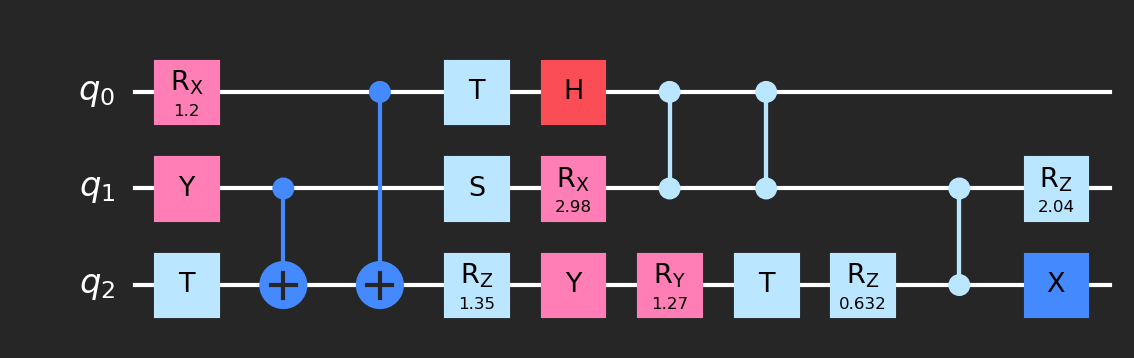

In [19]:
qc = qc_generator(3, 10, gate_density = 0.7, one_qubit_distribution = 0.7)

print(exact_expected_value(qc, observable))

qc.draw()

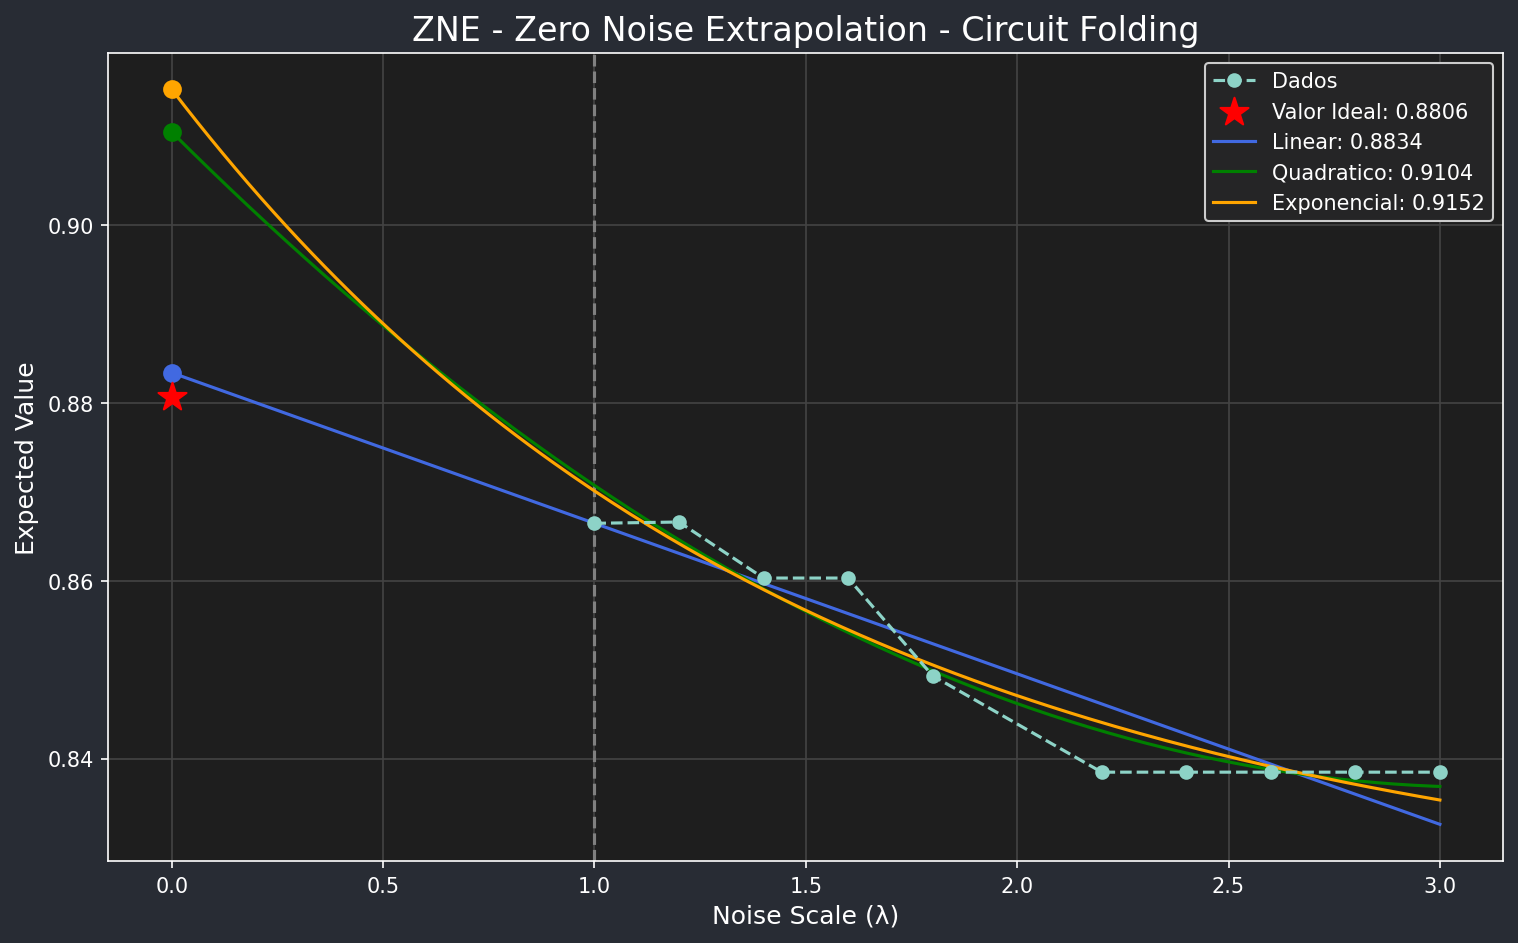

In [ ]:
zne_1 = zne(quantum_circuit=qc, observable=observable, lambda_range=(1.0, 3.0), num_points=10, folding_type='circuit', gate_folding_method='left', noise_model=noise_model, shots=1024, precision=None, coupling_map=coupling_map, basis_gates=basis_gates)

graph(zne_result = zne_1)

In [31]:
zne_gate_left = zne(quantum_circuit=qc, observable=observable, lambda_range=(1.0, 3.0), num_points=10, folding_type='gate', gate_folding_method='left', noise_model=noise_model, shots=1024, precision=None, coupling_map=coupling_map, basis_gates=basis_gates)

zne_gate_right = zne(quantum_circuit=qc, observable=observable, lambda_range=(1.0, 3.0), num_points=10, folding_type='gate', gate_folding_method='right', noise_model=noise_model, shots=1024, precision=None, coupling_map=coupling_map, basis_gates=basis_gates)

zne_gate_random = zne(quantum_circuit=qc, observable=observable, lambda_range=(1.0, 3.0), num_points=10, folding_type='gate', gate_folding_method='random', noise_model=noise_model, shots=1024, precision=None, coupling_map=coupling_map, basis_gates=basis_gates)

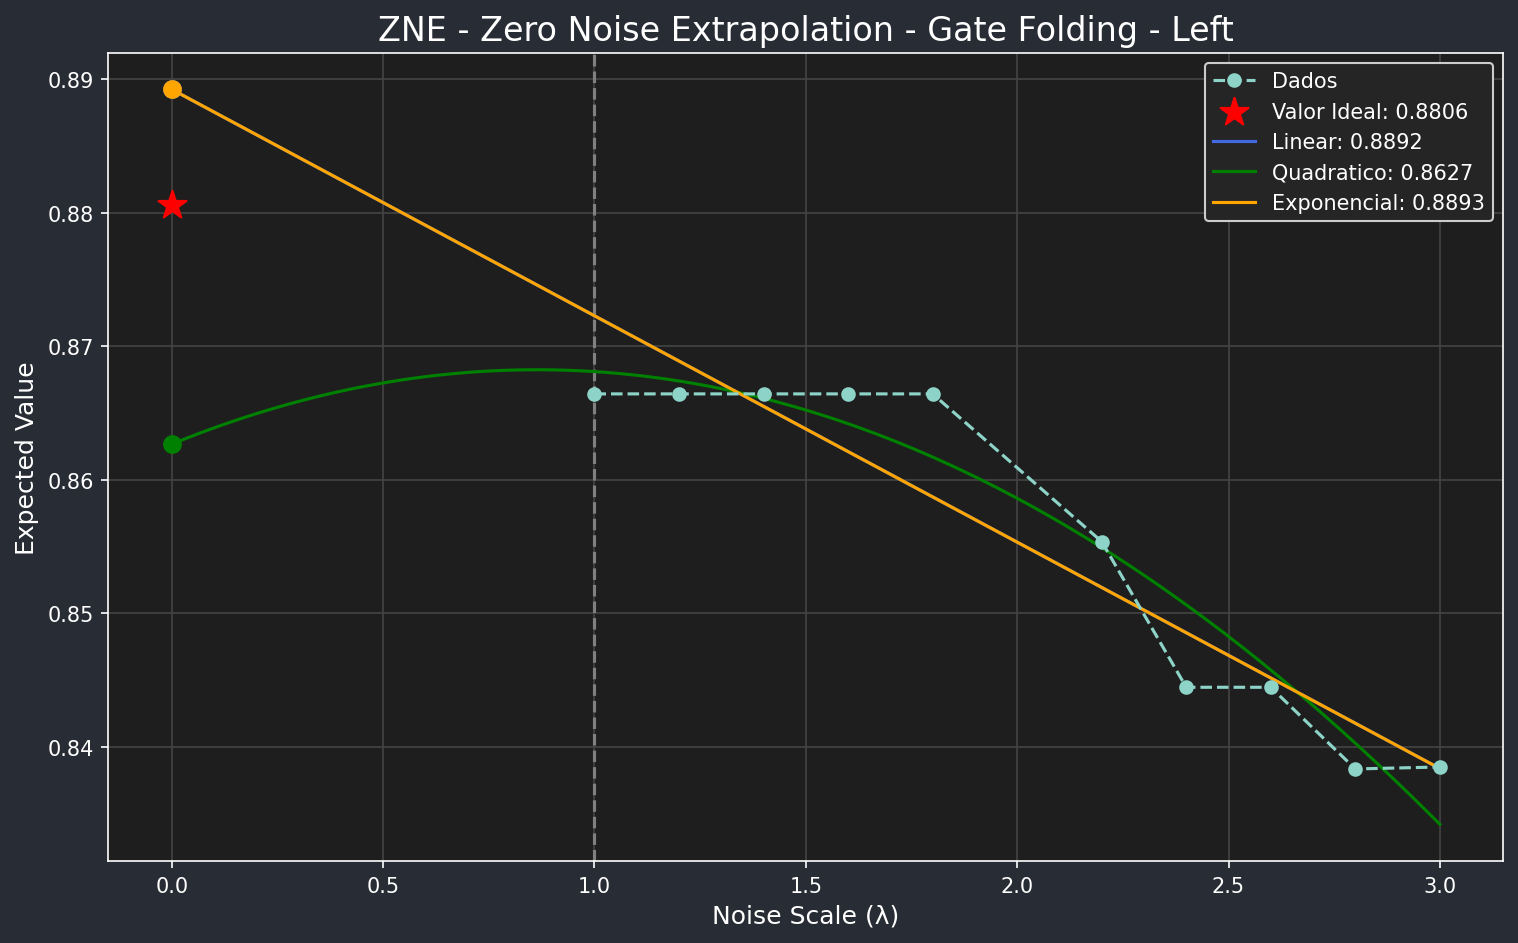

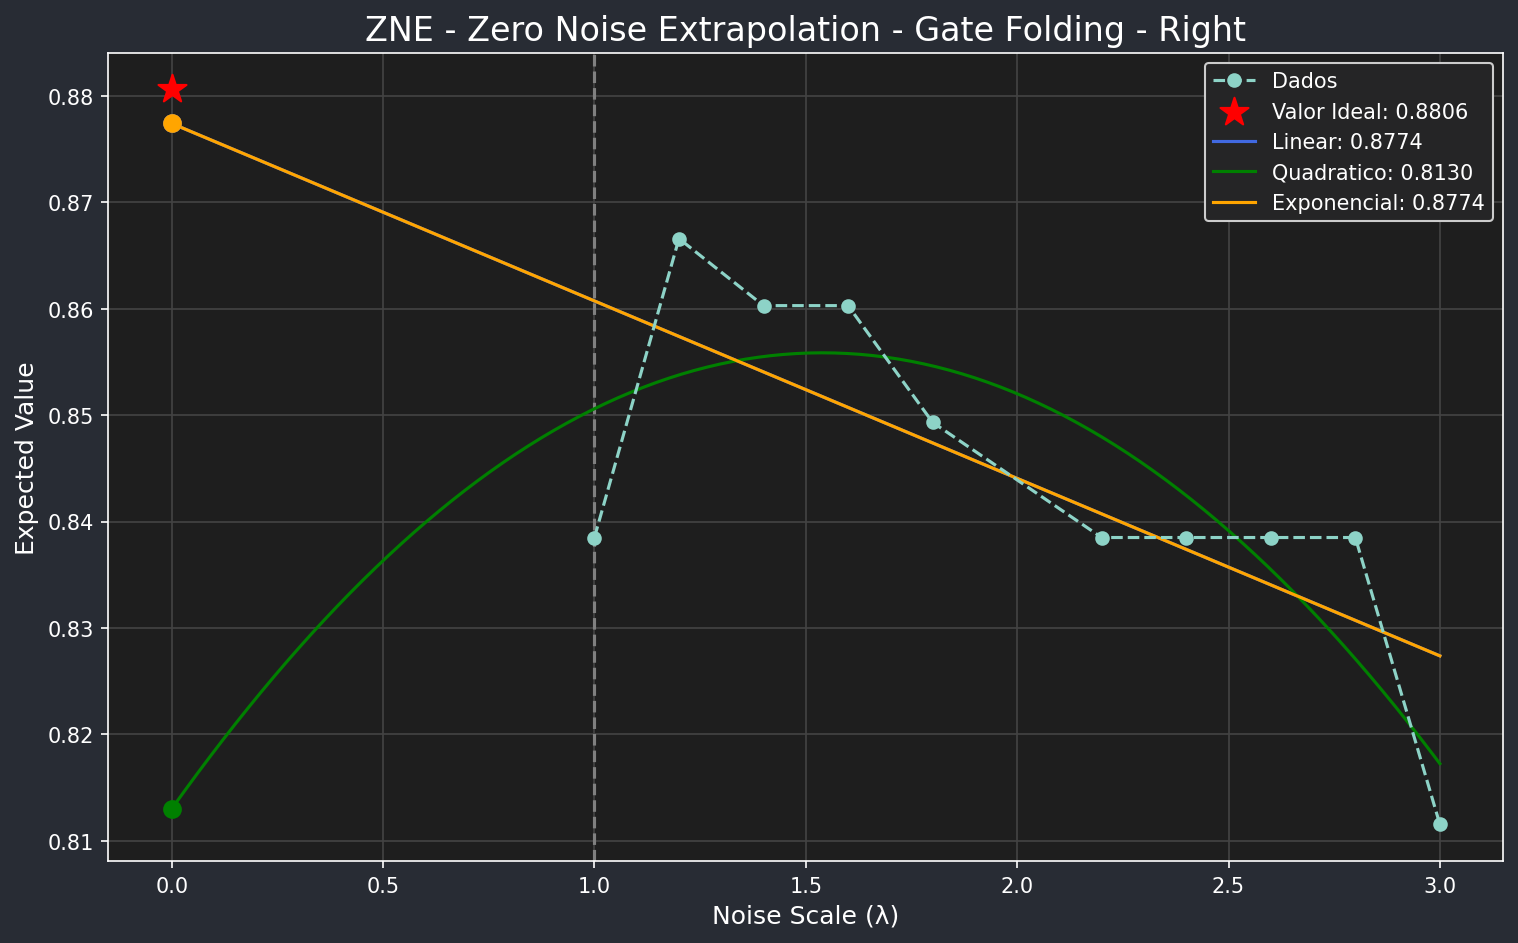

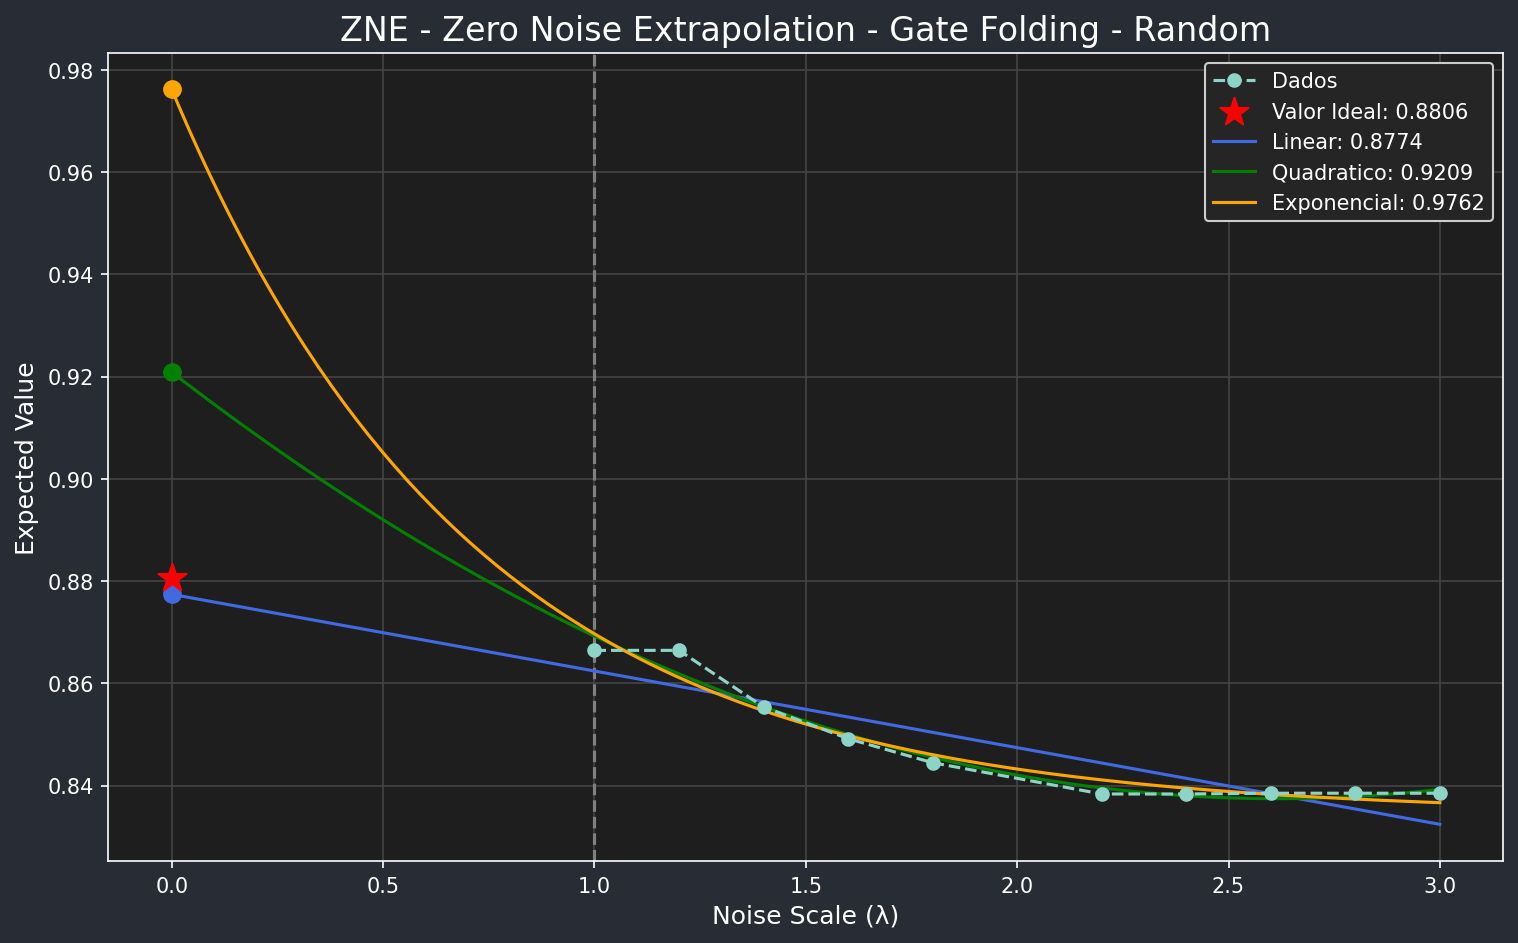

In [38]:
graph(zne_result = zne_gate_left)
graph(zne_result = zne_gate_right)
graph(zne_result = zne_gate_random)